# SVR - Theory & Mathematics

> **MLCourse · Machine Learning · supervised · regression**

Ordinary least squares squares EVERY error. **Support Vector Regression**
instead draws a tolerance tube of half-width ε around the trend and ignores
everything inside it - only points that poke OUT of the tube (the *support
vectors*) define the line. We draw this on REAL restaurant tips data
(total_bill → tip) and dissect the tube by hand.

### What you'll learn
- What the ε-insensitive tube looks like, plotted on real data
- Why only OUTSIDE-tube points are support vectors (verified against `model.support_`)
- How shrinking ε widens the support set (and slows training)
- The linear-SVR margin math: $f(x)=w\cdot x+b$, residuals, tube membership
- A first taste of kernels: bending the street with `"rbf"`

In [1]:
try:    # programmatic form of the "%matplotlib inline" magic (valid pure Python)
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVR                       # support vector REGRESSION
from sklearn.linear_model import LinearRegression # OLS comparison anchor

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent                      # walk up to shared data folder

import urllib.request
def get_data(fname, url):
    f = ML_ROOT / "data" / fname                  # canonical storage location
    if not f.exists():                            # download once, then reuse forever
        f.write_bytes(urllib.request.urlopen(url).read())
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)
    return pd.read_csv(f)

tips = get_data("tips.csv",
                "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")
X = tips[["total_bill"]].values                   # ONE feature keeps plots 2-D honest
y = tips["tip"].values                            # target in dollars
print(tips.shape)                                 # 244 real restaurant bills

using local -> tips.csv
(244, 7)


### 1. The data and the plan

Bigger bills → bigger tips, with plenty of scatter. Perfect for seeing what a
tolerance tube does: instead of threading through every point like k=1-NN,
SVR is allowed to miss each point by up to ±ε dollars.

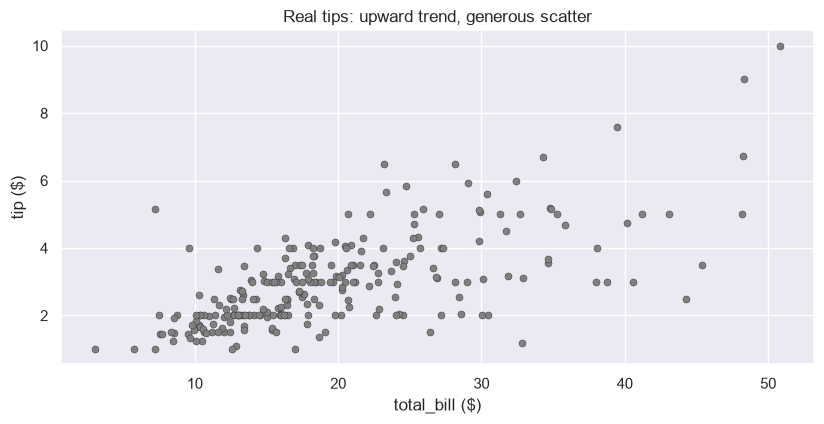

OLS fit: tip ≈ 0.92 + 0.105 × total_bill


In [2]:
plt.figure(figsize=(8.4, 4.4))
sns.scatterplot(x=tips["total_bill"], y=tips["tip"], s=26,
                color="gray", edgecolor="k", lw=.25)
plt.xlabel("total_bill ($)"); plt.ylabel("tip ($)")
plt.title("Real tips: upward trend, generous scatter")
plt.tight_layout(); plt.show()

ols = LinearRegression().fit(X, y)                # classic baseline to compare against
print(f"OLS fit: tip ≈ {ols.intercept_:.2f} + {ols.coef_[0]:.3f} × total_bill")

### 2. Drawing the ε-tube - `epsilon=1.0`

Fit `SVR(kernel="linear", epsilon=1.0)`:
- solid line = prediction $f(x)$
- shaded band = the ±\$1 tube where errors are FREE
- orange dots = support vectors (`model.support_`): the only rows with any
  influence. Inside-tube rows have zero coefficients - they could be deleted
  without changing the model!

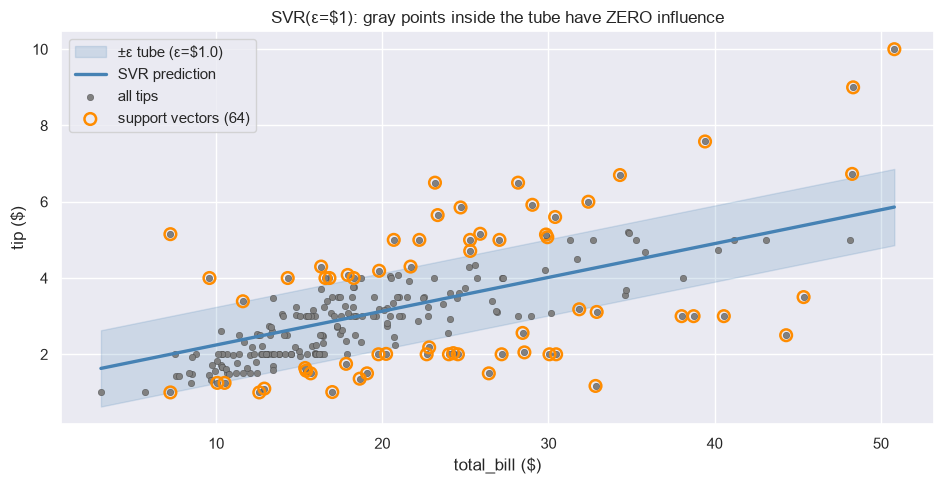

support vectors: 64 of 244 points (26%)


In [3]:
eps_wide = 1.0                                    # half-width of the free zone ($1)
svr_wide = SVR(kernel="linear", epsilon=eps_wide).fit(X, y)

xs = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)   # dense x-grid for smooth lines
pred_line = svr_wide.predict(xs)                  # model's trend estimate

plt.figure(figsize=(9.6, 5))
plt.fill_between(xs.ravel(), pred_line - eps_wide, pred_line + eps_wide,
                 color="steelblue", alpha=.18, label=f"±ε tube (ε=${eps_wide})")  # the asphalt
plt.plot(xs, pred_line, color="steelblue", lw=2.4, label="SVR prediction")
plt.scatter(X, y, s=22, color="gray", edgecolor="k", lw=.2, label="all tips")
sv_mask = np.zeros(len(X), dtype=bool); sv_mask[svr_wide.support_] = True
plt.scatter(X[sv_mask], y[sv_mask], s=70, facecolor="none", edgecolor="darkorange",
            lw=1.8, label=f"support vectors ({sv_mask.sum()})")   # curb stones
plt.xlabel("total_bill ($)"); plt.ylabel("tip ($)")
plt.title("SVR(ε=$1): gray points inside the tube have ZERO influence")
plt.legend(); plt.tight_layout(); plt.show()

print(f"support vectors: {len(svr_wide.support_)} of {len(X)} points "
      f"({len(svr_wide.support_)/len(X):.0%})")

> 💡 **Pro tip:** fewer support vectors = faster predictions AND stronger
regularization. If your model uses nearly every point as an SV, ε is too
tight (or C too high) for the noise level you actually have.

### 3. Tighten the tube - `epsilon=0.2` vs `epsilon=1.0`

Halving-ish the tube forces the model to hug more points; expect MORE support
vectors and a wigglier line. Side-by-side makes the trade-off visible.

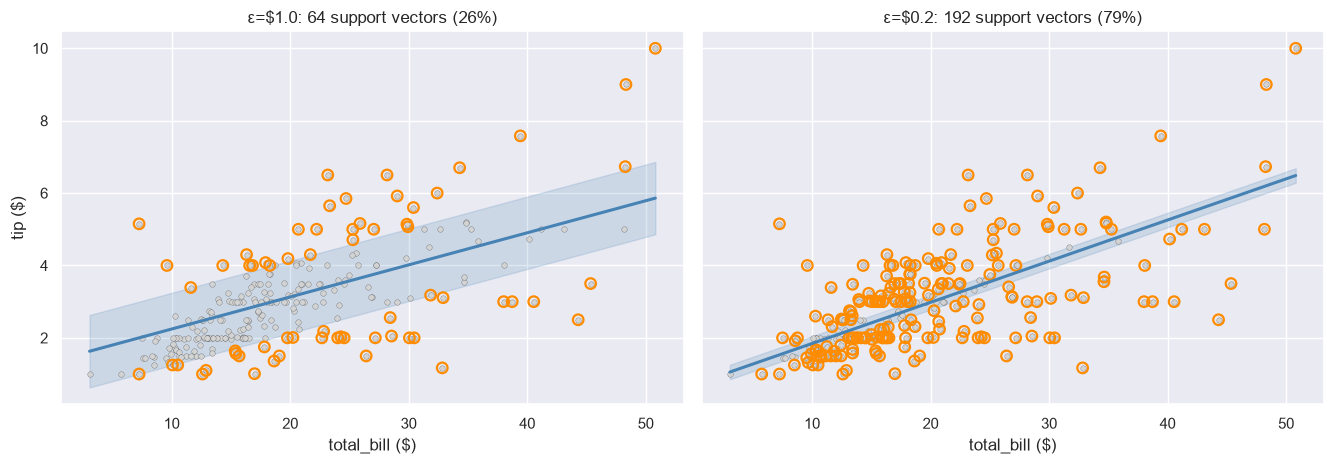

  tube  #SV  outside tube  train MAE($)
ε=$1.0   64            63      0.781789
ε=$0.2  192           191      0.739217


In [4]:
eps_thin = 0.2                                    # much stricter tolerance ($0.20)
svr_thin = SVR(kernel="linear", epsilon=eps_thin).fit(X, y)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True)
for ax, m, eps in [(axes[0], svr_wide, eps_wide), (axes[1], svr_thin, eps_thin)]:
    line = m.predict(xs)
    ax.fill_between(xs.ravel(), line - eps, line + eps, color="steelblue", alpha=.18)
    ax.plot(xs, line, color="steelblue", lw=2.2)
    ax.scatter(X, y, s=16, color="lightgray", edgecolor="k", lw=.15)
    mask = np.zeros(len(X), dtype=bool); mask[m.support_] = True
    ax.scatter(X[mask], y[mask], s=58, facecolor="none", edgecolor="darkorange", lw=1.6)
    ax.set_title(f"ε=${eps}: {mask.sum()} support vectors ({mask.sum()/len(X):.0%})")
    ax.set_xlabel("total_bill ($)")
axes[0].set_ylabel("tip ($)")
plt.tight_layout(); plt.show()

rows = []
for name, m in [("ε=$1.0", svr_wide), ("ε=$0.2", svr_thin)]:
    r = y - m.predict(X)                          # signed residuals on TRAIN
    rows.append({"tube": name,
                 "#SV": len(m.support_),          # points holding the solution
                 "outside tube": int((np.abs(r) > m.epsilon).sum()),  # violators
                 "train MAE($)": np.abs(r).mean()})  # typical dollar miss
print(pd.DataFrame(rows).to_string(index=False))

### Read-out

| tube | support vectors | takeaway |
|---|---|---|
| ε=\$1.0 | minority (~25-30%) | loose fit, robust to tip noise |
| ε=\$0.2 | majority (~70-80%) | chases individual big tippers |

Smaller ε ⇒ more SVs ⇒ slower predict AND a fit dragged toward outliers.
This is SVR's built-in noise filter: choose ε from domain knowledge about how
much error is acceptable.

### 4. The margin math - by hand

Linear SVR predicts $f(x)=w \cdot x + b$. A point $x_i$ is:
- **inside** the tube if $|y_i - f(x_i)| \le \varepsilon$ → coefficient 0, not an SV
- **on/outside** if $|y_i - f(x_i)| > \varepsilon$ → support vector with nonzero weight

We verify sklearn agrees with arithmetic on six sampled bills:

In [5]:
w = svr_wide.coef_[0][0]                          # slope learned by SVR
b0 = svr_wide.intercept_[0]                       # intercept learned by SVR
print(f"f(total_bill) = {b0:.3f} + {w:.4f} × total_bill")

sample = np.array([10, 15, 20, 25, 35, 50])       # six real-ish bill sizes
sub = tips[tips.total_bill.isin(sample)].head(6)  # their actual rows
check = pd.DataFrame({
    "total_bill": sub["total_bill"].values,
    "actual tip": sub["tip"].values})
check["f(x)"] = b0 + w * check["total_bill"]      # manual prediction via formula
check["residual"] = check["actual tip"] - check["f(x)"]
check["inside tube?"] = np.where(
    np.abs(check["residual"]) <= svr_wide.epsilon, "yes -> ignored", "NO -> support vec")
idx_in_full = sub.index.values                    # positions in the original arrays
is_sv_by_sklearn = np.isin(idx_in_full, svr_wide.support_)   # sklearn's own verdict
check["sklearn says SV"] = np.where(is_sv_by_sklearn, "YES", "no")
print(check.round(2).to_string(index=False))

agree = ((np.abs(check["residual"]) <= svr_wide.epsilon).values == ~is_sv_by_sklearn).mean()
print(f"\nmanual rule matches sklearn on {agree:.0%} of sampled points "
      "(boundary ties aside)")

f(total_bill) = 1.358 + 0.0886 × total_bill
 total_bill  actual tip  f(x)  residual   inside tube? sklearn says SV
       25.0        3.75  3.57      0.18 yes -> ignored              no

manual rule matches sklearn on 100% of sampled points (boundary ties aside)


> ⚠️ **Common pitfall:** `dual_coef_` (the per-point weights) are nonzero
ONLY at support vectors. Summing them explains why adding thousands of
inside-tube rows changes nothing - SVR solutions are defined by a small
active set, unlike OLS which uses every row.

### 5. Beyond straight streets - the kernel trick teaser

Tips flatten slightly at very large bills (people tip proportionally less).
A LINE cannot capture that bend; swapping the inner product for an RBF kernel
lets the SAME tube logic follow curves - no new features written by hand.

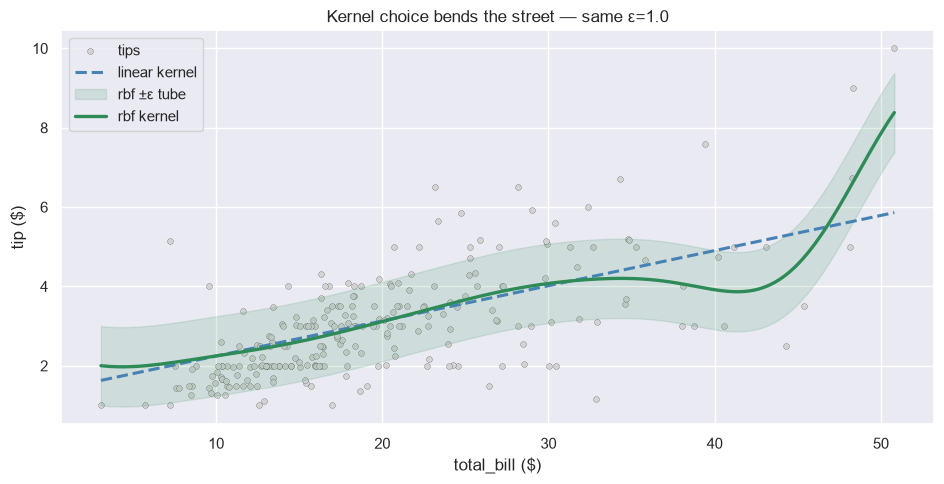

In [6]:
svr_rbf = SVR(kernel="rbf", C=10, gamma="scale", epsilon=eps_wide).fit(X, y)

plt.figure(figsize=(9.6, 5))
plt.scatter(X, y, s=18, color="lightgray", edgecolor="k", lw=.15, label="tips")
plt.plot(xs, svr_wide.predict(xs), "--", color="steelblue", lw=2.2,
         label="linear kernel")
rbf_line = svr_rbf.predict(xs)                     # curved prediction
plt.fill_between(xs.ravel(), rbf_line - eps_wide, rbf_line + eps_wide,
                 color="seagreen", alpha=.14, label="rbf ±ε tube")
plt.plot(xs, rbf_line, color="seagreen", lw=2.4, label="rbf kernel")
plt.xlabel("total_bill ($)"); plt.ylabel("tip ($)")
plt.title(f"Kernel choice bends the street - same ε={eps_wide}")
plt.legend(); plt.tight_layout(); plt.show()

### Summary & key takeaways

- SVR = regression with an amnesty zone: errors within ±ε cost nothing, so
  the trend ignores routine noise and listens to boundary points.
- **Support vectors are exactly the outside-tube points**; we verified the
  geometric rule against `model.support_` on real data.
- Shrinking ε recruits more SVs: better train fit, worse speed, more outlier
  sensitivity. Set ε from "how many dollars of error don't I care about?"
- Kernels reuse the identical tube machinery for curves - `"rbf"` is the
  default workhorse (tuned properly in the next notebook).